# 01 — Profiling inicial

O objetivo desta etapa é validar a integridade do Parquet bruto e perfilar a base antes de qualquer tratamento. É o primeiro momento para identificar problemas estruturais (encoding, separadores, padrões de missing) antes de investir tempo em limpeza.

**Input:** `data/raw/INFLUD23-23-03-2026.parquet` — 22 MB, 279.453 linhas e 194 colunas (output da Fase 0).

Os outputs desta etapa são:

- Schema documentado, com investigação da discrepância de 194 contra 184 colunas.
- Mapa de missing por coluna (top 30 e colunas 100% nulas, candidatas a drop imediato).
- Range temporal de `DT_NOTIFIC` (sanity-check do escopo de 2023).
- Cardinalidade por coluna (constantes e quase-constantes).
- Distribuição da variável-alvo `EVOLUCAO` e do agente etiológico `CLASSI_FIN`.

As decisões que esta fase informa para a etapa de tratamento (Fase 2) são:

- Quais colunas dropar imediatamente (100% missing, constantes, ruído de parsing).
- Estratégia de imputação por coluna (mediana ou moda mais indicador binário de missing).
- Validade do split temporal proposto (1º contra 2º semestre), dependente da distribuição mensal de notificações.
- Tamanho efetivo da base de modelagem (apenas `EVOLUCAO ∈ {1, 2}`).

In [1]:
"""Setup: imports, paths, configurações de display."""
from io import StringIO

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd

from maxpar_srag import config
from maxpar_srag.data import load_raw

# Display: mostrar mais colunas/linhas que o default mas ainda truncado.
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 200)

# Pasta para figuras desta fase.
FIG_DIR = config.FIGURES_DIR / "01_profiling"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"pandas {pd.__version__}")
print(f"figures → {FIG_DIR.relative_to(config.PROJECT_ROOT)}")

pandas 3.0.2
figures → reports\figures\01_profiling


## 1. Carregamento

O ecossistema downstream (scikit-learn, lightgbm, xgboost, shap, missingno, seaborn) é majoritariamente pandas-first. Por isso `load_raw()` retorna pandas por default; polars permanece disponível via `engine="polars"` quando o ganho compensa.

In [2]:
df = load_raw()  # default engine="pandas"

n_rows, n_cols = df.shape
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Shape         : {n_rows:,} linhas × {n_cols} colunas")
print(f"Memória (deep): {mem_mb:,.1f} MB")
print(f"Dtypes        : {df.dtypes.value_counts().to_dict()}")

Shape         : 279,453 linhas × 194 colunas
Memória (deep): 838.9 MB
Dtypes        : {<StringDtype(na_value=nan)>: 150, dtype('<M8[ns]'): 23, dtype('O'): 21}


## 2. Schema — investigação de 194 contra 184 colunas

O dicionário oficial do SIVEP-Gripe lista cerca de 184 colunas para 2023. O Parquet em uso tem 194. Cabe investigar a origem das cerca de 10 colunas extras.

Duas hipóteses possíveis:

1. Separadores trailing (`;` no fim das linhas) durante o parsing do CSV gerando colunas auto-geradas com nomes anômalos (`Unnamed*`, `Column_*` ou vazio).
2. O DataSUS adicionou colunas em revisões recentes do dicionário (por exemplo, campos de vacinação COVID e vigilância genômica) que não estão na lista hardcoded em `config.py`.

A expectativa é a hipótese 2. As listas em `config.py` (`BINARY_FIELDS`, `DATE_COLUMNS`) são parciais por construção; enumeram apenas o que é necessário para o cleaning.

In [3]:
"""Listar todas as colunas e identificar nomes anômalos (auto-gerados)."""
all_cols = list(df.columns)
print(f"Total: {len(all_cols)} colunas\n")

anomalous_prefixes = ("Unnamed", "_duplicated", "Column", "field_")
suspeitas = [c for c in all_cols if c.startswith(anomalous_prefixes) or c.strip() == ""]
print(f"Colunas com nomes anômalos (auto-geradas pelo parsing): {len(suspeitas)}")
if suspeitas:
    for c in suspeitas:
        print(f"  {c!r}")

print("\nListagem completa (10 por linha):")
for i in range(0, len(all_cols), 10):
    print(f"  [{i:3d}] " + ", ".join(all_cols[i : i + 10]))

Total: 194 colunas

Colunas com nomes anômalos (auto-geradas pelo parsing): 0

Listagem completa (10 por linha):
  [  0] NU_NOTIFIC, DT_NOTIFIC, SEM_NOT, DT_SIN_PRI, SEM_PRI, SG_UF_NOT, ID_REGIONA, CO_REGIONA, ID_MUNICIP, CO_MUN_NOT
  [ 10] CS_SEXO, DT_NASC, NU_IDADE_N, TP_IDADE, COD_IDADE, CS_GESTANT, CS_RACA, CS_ETINIA, CS_ESCOL_N, ID_PAIS
  [ 20] CO_PAIS, SG_UF, ID_RG_RESI, CO_RG_RESI, ID_MN_RESI, CO_MUN_RES, CS_ZONA, NOSOCOMIAL, AVE_SUINO, FEBRE
  [ 30] TOSSE, GARGANTA, DISPNEIA, DESC_RESP, SATURACAO, DIARREIA, VOMITO, OUTRO_SIN, OUTRO_DES, FATOR_RISC
  [ 40] PUERPERA, CARDIOPATI, HEMATOLOGI, SIND_DOWN, HEPATICA, ASMA, DIABETES, NEUROLOGIC, PNEUMOPATI, IMUNODEPRE
  [ 50] RENAL, OBESIDADE, OBES_IMC, OUT_MORBI, MORB_DESC, TABAG, VACINA, DT_UT_DOSE, MAE_VAC, DT_VAC_MAE
  [ 60] M_AMAMENTA, DT_DOSEUNI, DT_1_DOSE, DT_2_DOSE, ANTIVIRAL, TP_ANTIVIR, OUT_ANTIV, DT_ANTIVIR, HOSPITAL, DT_INTERNA
  [ 70] SG_UF_INTE, ID_RG_INTE, CO_RG_INTE, ID_MN_INTE, CO_MU_INTE, NM_UN_INTE, UTI, DT_ENTUTI, DT

In [4]:
"""Cruzamento com colunas que conhecemos pelo dicionário."""
known = set(
    config.BINARY_FIELDS
    + config.DATE_COLUMNS
    + [
        "NU_NOTIFIC", "CS_SEXO", "CS_GESTANT", "CS_RACA", "CS_ESCOL_N",
        "CS_ZONA", "NU_IDADE_N", "TP_IDADE",
        "SG_UF", "SG_UF_NOT", "ID_REGIONA", "ID_MUNICIP", "ID_RG_RESI",
        "CLASSI_FIN", "CRITERIO", "EVOLUCAO",
        "SUPORT_VEN", "RAIOX_RES", "TP_AMOSTRA",
        "TP_FLU_PCR", "PCR_FLUASU", "PCR_FLUBLI",
    ]
)
presentes_no_dict = [c for c in all_cols if c in known]
fora_do_dict = [c for c in all_cols if c not in known]
print(f"Colunas presentes no dicionário hardcoded : {len(presentes_no_dict)}")
print(f"Colunas fora do dicionário hardcoded      : {len(fora_do_dict)}")
print()
print("Primeiras 30 'fora do dicionário' (esperado: nomes legítimos não enumerados em config.py):")
for c in fora_do_dict[:30]:
    print(f"  {c}")

Colunas presentes no dicionário hardcoded : 97
Colunas fora do dicionário hardcoded      : 97

Primeiras 30 'fora do dicionário' (esperado: nomes legítimos não enumerados em config.py):
  SEM_NOT
  SEM_PRI
  CO_REGIONA
  CO_MUN_NOT
  COD_IDADE
  CS_ETINIA
  ID_PAIS
  CO_PAIS
  CO_RG_RESI
  ID_MN_RESI
  CO_MUN_RES
  OUTRO_SIN
  OUTRO_DES
  OBES_IMC
  MORB_DESC
  TP_ANTIVIR
  OUT_ANTIV
  SG_UF_INTE
  ID_RG_INTE
  CO_RG_INTE
  ID_MN_INTE
  CO_MU_INTE
  NM_UN_INTE
  RAIOX_OUT
  OUT_AMOST
  POS_PCRFLU
  FLUASU_OUT
  FLUBLI_OUT
  POS_PCROUT
  PCR_VSR


## 3. Análise de missing

Os objetivos desta análise são:

- Identificar colunas 100% missing, com drop imediato na Fase 2.
- Identificar colunas com missing alto, mas inferior a 100%, com decisão por coluna (drop, imputação ou indicador binário).
- Examinar o padrão visual de missing (missingno), útil para detectar correlações de missing entre colunas relacionadas.

In [5]:
"""% missing por coluna — distribuição global e top 30."""
pct_missing = (df.isna().mean() * 100).sort_values(ascending=False)

print("Resumo:")
print(f"  Colunas 100% missing : {(pct_missing == 100).sum()}")
print(f"  Colunas >50% missing : {(pct_missing > 50).sum()}")
print(f"  Colunas >0%  missing : {(pct_missing > 0).sum()} / {len(pct_missing)}")
print(f"  Colunas 0%   missing : {(pct_missing == 0).sum()}")
print()
print("Top 30 % missing:")
print(pct_missing.head(30).round(2).to_string())
print()
print("Bottom 10 % missing (colunas mais completas):")
print(pct_missing.tail(10).round(2).to_string())

Resumo:
  Colunas 100% missing : 7
  Colunas >50% missing : 117
  Colunas >0%  missing : 176 / 194
  Colunas 0%   missing : 18

Top 30 % missing:
TABAG         100.00
DT_RT_VGM     100.00
PAIS_VGM      100.00
LO_PS_VGM     100.00
VG_REINF      100.00
DT_VGM        100.00
CO_PS_VGM     100.00
AN_PARA2      100.00
FLUBLI_OUT    100.00
FLUASU_OUT     99.99
AN_PARA1       99.98
AN_PARA3       99.98
AN_ADENO       99.98
PCR_PARA2      99.95
PCR_PARA4      99.95
VG_METOUT      99.95
VG_OMSOUT      99.92
DT_2_DOSE      99.92
PCR_PARA1      99.90
DT_DOSEUNI     99.89
DT_1_DOSE      99.88
DS_AN_OUT      99.87
AN_OUTRO       99.86
DT_VAC_MAE     99.78
OUT_TRAT       99.78
OBES_IMC       99.77
OUT_SOR        99.73
OUT_ANTIV      99.70
DT_TRT_COV     99.69
OUT_ANIM       99.68

Bottom 10 % missing (colunas mais completas):
SEM_NOT       0.0
DT_SIN_PRI    0.0
ID_PAIS       0.0
NU_IDADE_N    0.0
CO_PAIS       0.0
DT_DIGITA     0.0
HISTO_VGM     0.0
TEM_CPF       0.0
POV_CT        0.0
FNT_IN_COV    0

In [6]:
"""Listar TODAS as colunas 100% missing — candidatas a drop imediato na Fase 2."""
fully_empty = pct_missing[pct_missing == 100].index.tolist()
print(f"Colunas 100% missing ({len(fully_empty)}):")
for c in fully_empty:
    print(f"  {c}")

Colunas 100% missing (7):
  TABAG
  DT_RT_VGM
  PAIS_VGM
  LO_PS_VGM
  VG_REINF
  DT_VGM
  CO_PS_VGM


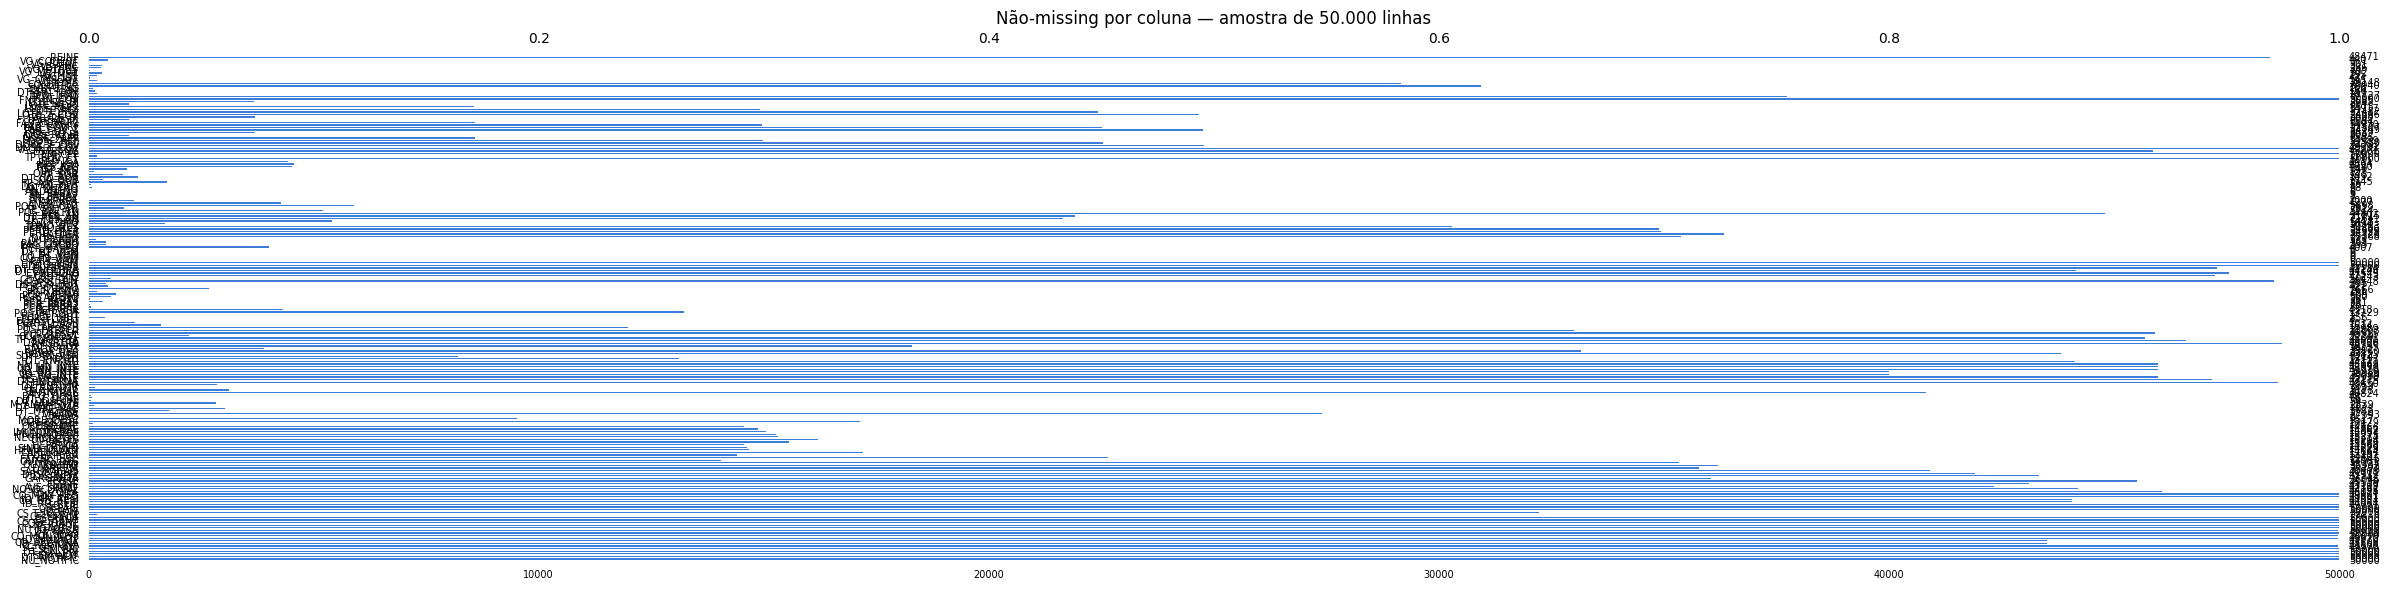

Figura salva: reports\figures\01_profiling\01_missing_bar.png


In [7]:
"""Visualização: missingno bar chart em uma amostra.

Subset de 50k linhas com seed fixo: padrão de missing em N=50k é representativo
do conjunto inteiro e a viz fica legível em RAM razoável.
"""
sample = df.sample(50_000, random_state=config.RANDOM_STATE)

fig, ax = plt.subplots(figsize=(24, 6))
msno.bar(sample, ax=ax, fontsize=7, color="#3b7dd8")
ax.set_title("Não-missing por coluna — amostra de 50.000 linhas")
plt.tight_layout()
fig_path = FIG_DIR / "01_missing_bar.png"
plt.savefig(fig_path, dpi=110, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

## 4. Range temporal — `DT_NOTIFIC`

Como sanity-check, todos os casos devem cair em 2023. Casos fora desse range indicam contaminação ou mistura de datasets e exigem filtragem na Fase 2.

A distribuição mensal também é avaliada aqui, pois informa a viabilidade do split temporal de 1º contra 2º semestre proposto na Fase 4.

In [8]:
"""Parse DT_NOTIFIC e checa range temporal."""
# SIVEP-Gripe usa formato dd/mm/aaaa
dt_notif = pd.to_datetime(df["DT_NOTIFIC"], format="%d/%m/%Y", errors="coerce")

print(f"Range observado : {dt_notif.min()} → {dt_notif.max()}")
print(f"Não parseáveis  : {dt_notif.isna().sum():,} ({dt_notif.isna().mean() * 100:.3f}%)")
print()
anos = dt_notif.dt.year.value_counts().sort_index()
print("Casos por ano:")
print(anos.to_string())
print()
fora_2023 = ((dt_notif.dt.year != 2023) & dt_notif.notna()).sum()
print(f"Casos com DT_NOTIFIC fora de 2023: {fora_2023:,}")

Range observado : 2023-01-01 00:00:00 → 2025-06-23 00:00:00
Não parseáveis  : 0 (0.000%)

Casos por ano:
DT_NOTIFIC
2023    276339
2024      3100
2025        14

Casos com DT_NOTIFIC fora de 2023: 3,114


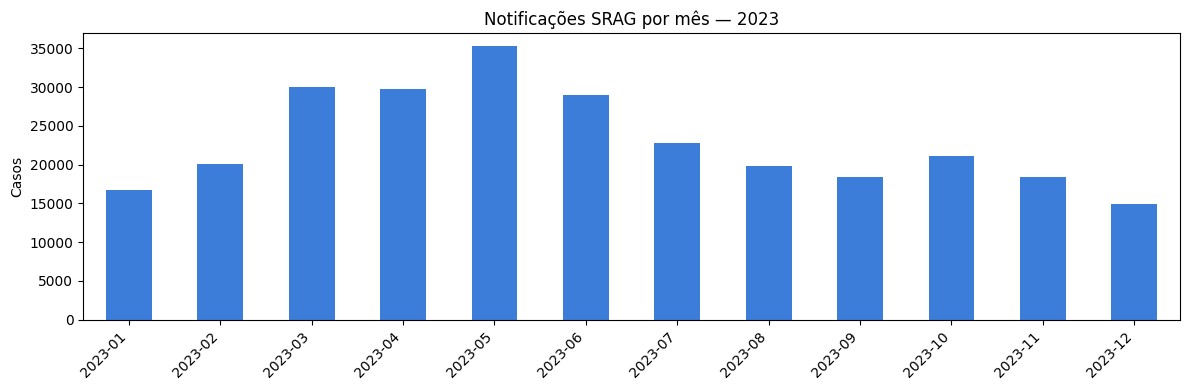

Casos por mês:
DT_NOTIFIC
2023-01    16738
2023-02    20072
2023-03    29965
2023-04    29787
2023-05    35248
2023-06    29026
2023-07    22809
2023-08    19881
2023-09    18374
2023-10    21117
2023-11    18440
2023-12    14882
Freq: M

Split potencial 1º × 2º semestre:
  1º sem (treino): 160,836 (58.2%)
  2º sem (teste) : 115,503 (41.8%)


In [9]:
"""Distribuição mensal de notificações."""
mensal = (
    dt_notif[dt_notif.dt.year == 2023]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
mensal.plot(kind="bar", ax=ax, color="#3b7dd8")
ax.set_title("Notificações SRAG por mês — 2023")
ax.set_ylabel("Casos")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig_path = FIG_DIR / "02_notif_mensal.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()

print("Casos por mês:")
print(mensal.to_string())

# Sanity para o split temporal: distribuição 1º vs 2º semestre.
primeiro_sem = dt_notif[(dt_notif.dt.year == 2023) & (dt_notif.dt.month <= 6)].size
segundo_sem = dt_notif[(dt_notif.dt.year == 2023) & (dt_notif.dt.month >= 7)].size
total_2023 = primeiro_sem + segundo_sem
print(f"\nSplit potencial 1º × 2º semestre:")
print(f"  1º sem (treino): {primeiro_sem:,} ({primeiro_sem/total_2023*100:.1f}%)")
print(f"  2º sem (teste) : {segundo_sem:,} ({segundo_sem/total_2023*100:.1f}%)")

## 5. Cardinalidade

- **Constantes** (um único valor): coluna sem informação, com drop imediato.
- **Quase-constantes** (mais de 99% concentração em um valor): variância negligenciável; candidatas a drop ou conversão em binária do tipo "é o valor dominante".
- **Alta cardinalidade** (por exemplo, município, código IBGE): não entram cruas em modelos lineares; exigem target encoding ou agregação.

In [10]:
"""Cardinalidade global."""
nunique = df.nunique(dropna=True).sort_values()

print("Distribuição de cardinalidade:")
print(f"  =0 (vazia)        : {(nunique == 0).sum()}")
print(f"  =1 (constante)    : {(nunique == 1).sum()}")
print(f"  =2                : {(nunique == 2).sum()}")
print(f"  3-10              : {((nunique >= 3) & (nunique <= 10)).sum()}")
print(f"  11-100            : {((nunique > 10) & (nunique <= 100)).sum()}")
print(f"  101-1.000         : {((nunique > 100) & (nunique <= 1_000)).sum()}")
print(f"  >1.000            : {(nunique > 1_000).sum()}")
print()
print("Bottom 25 (menor cardinalidade):")
print(nunique.head(25).to_string())
print()
print("Top 10 (maior cardinalidade):")
print(nunique.tail(10).to_string())

Distribuição de cardinalidade:
  =0 (vazia)        : 7
  =1 (constante)    : 21
  =2                : 7
  3-10              : 71
  11-100            : 17
  101-1.000         : 53
  >1.000            : 18

Bottom 25 (menor cardinalidade):
TABAG         0
LO_PS_VGM     0
DT_VGM        0
CO_PS_VGM     0
PAIS_VGM      0
DT_RT_VGM     0
VG_REINF      0
HISTO_VGM     1
PCR_METAP     1
PCR_ADENO     1
PCR_BOCA      1
PCR_PARA3     1
PCR_PARA4     1
PCR_VSR       1
PCR_PARA2     1
FATOR_RISC    1
PCR_RINO      1
PCR_OUTRO     1
PCR_SARS2     1
AN_VSR        1
AN_OUTRO      1
AN_PARA3      1
AN_PARA2      1
REINF         1
AN_ADENO      1

Top 10 (maior cardinalidade):
CO_MUN_NOT      1701
NM_UN_INTE      3427
TOMO_OUT        3931
ID_MN_RESI      4840
CO_MUN_RES      5090
RAIOX_OUT       7893
MORB_DESC      20425
OUTRO_DES      22839
DT_NASC        34479
NU_NOTIFIC    279453


In [11]:
"""Listar constantes e quase-constantes (>99% em um valor)."""
constantes = nunique[nunique == 1].index.tolist()
print(f"Colunas constantes (n=1): {len(constantes)}")
for c in constantes:
    val = df[c].dropna().iloc[0] if df[c].notna().any() else "(todos NaN)"
    print(f"  {c}: {val!r}")

print("\nColunas quase-constantes (>99% em um único valor não-nulo):")
quase_const = []
for c in df.columns:
    if c in constantes:
        continue
    s = df[c].dropna()
    if len(s) == 0:
        continue
    vc = s.value_counts(normalize=True)
    top_pct = vc.iloc[0]
    if top_pct > 0.99:
        quase_const.append((c, vc.index[0], top_pct, len(s)))

for c, val, pct, n in quase_const:
    print(f"  {c}: {val!r} = {pct*100:.2f}% (de {n:,} não-nulos)")
print(f"\nTotal quase-constantes: {len(quase_const)}")

Colunas constantes (n=1): 21
  HISTO_VGM: '0'
  PCR_METAP: '1'
  PCR_ADENO: '1'
  PCR_BOCA: '1'
  PCR_PARA3: '1'
  PCR_PARA4: '1'
  PCR_VSR: '1'
  PCR_PARA2: '1'
  FATOR_RISC: '1'
  PCR_RINO: '1'
  PCR_OUTRO: '1'
  PCR_SARS2: '1'
  AN_VSR: '1'
  AN_OUTRO: '1'
  AN_PARA3: '1'
  AN_PARA2: '1'
  REINF: '2'
  AN_ADENO: '1'
  AN_SARS2: '1'
  AN_PARA1: '1'
  PCR_PARA1: '1'

Colunas quase-constantes (>99% em um único valor não-nulo):


  ID_PAIS: 'BRASIL' = 99.98% (de 279,453 não-nulos)
  CO_PAIS: Decimal('1') = 99.98% (de 279,453 não-nulos)
  POV_CT: '2' = 99.65% (de 279,453 não-nulos)
  ESTRANG: '2' = 99.23% (de 256,802 não-nulos)
  FAB_RE_BI: '103 - COVID-19 PFIZER - COMIRNATY BIVALENTE' = 99.39% (de 20,871 não-nulos)

Total quase-constantes: 5


## 6. Distribuição da variável-alvo `EVOLUCAO`

A codificação SIVEP-Gripe é: 1 para cura, 2 para óbito por SRAG, 3 para óbito por outras causas e 9 para ignorado.

A modelagem (Fase 5) usa apenas os códigos 1 e 2. Aqui são calculados:

- Tamanho efetivo da base de modelagem.
- Taxa-base de óbitos (essencial para a escolha da métrica primária, AUC-PR, dado o desbalanceamento).

Contagem absoluta:
EVOLUCAO
(NaN)                       13980
1 — Cura                   226151
2 — Óbito SRAG              24944
3 — Óbito outras causas      8301
9 — Ignorado                 6077

% sobre o total:
EVOLUCAO
(NaN)                        5.0
1 — Cura                   80.93
2 — Óbito SRAG              8.93
3 — Óbito outras causas     2.97
9 — Ignorado                2.17


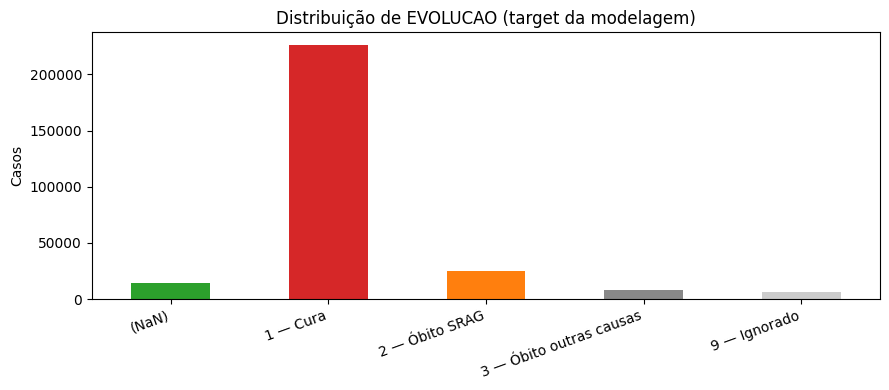


Total de casos             : 279,453


Casos modeláveis (1 ou 2)  : 251,095 (89.9%)
Óbitos SRAG (taxa-base)    : 24,944 (9.9% dos modeláveis)


In [12]:
"""Distribuição de EVOLUCAO."""
evol = df["EVOLUCAO"].astype("string").fillna("(NaN)")
counts = evol.value_counts(dropna=False).sort_index()

labels = {
    "1": "1 — Cura",
    "2": "2 — Óbito SRAG",
    "3": "3 — Óbito outras causas",
    "9": "9 — Ignorado",
    "(NaN)": "(NaN)",
}
labeled = counts.rename(index=labels)

print("Contagem absoluta:")
print(labeled.to_string())
print()
print("% sobre o total:")
print((labeled / labeled.sum() * 100).round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
labeled.plot(kind="bar", ax=ax, color=["#2ca02c", "#d62728", "#ff7f0e", "#888888", "#cccccc"])
ax.set_title("Distribuição de EVOLUCAO (target da modelagem)")
ax.set_ylabel("Casos")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig_path = FIG_DIR / "03_evolucao.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()

total = len(df)
modelaveis = (df["EVOLUCAO"].isin(["1", "2"])).sum()
obitos = (df["EVOLUCAO"] == "2").sum()
print(f"\nTotal de casos             : {total:,}")
print(f"Casos modeláveis (1 ou 2)  : {modelaveis:,} ({modelaveis/total*100:.1f}%)")
print(f"Óbitos SRAG (taxa-base)    : {obitos:,} ({obitos/modelaveis*100:.1f}% dos modeláveis)")

## 7. Distribuição de `CLASSI_FIN` (agente etiológico)

Para 2023, espera-se predominância de COVID-19 (código 5) ainda alta, embora decrescente em relação a 2022, com Influenza (código 1) e "outros vírus" (código 2, principalmente VSR) ganhando peso. Confirmar empiricamente.

Contagem absoluta:
CLASSI_FIN
(NaN)                             8382
1 — Influenza                    13442
2 — Outro vírus respiratório     49065
3 — Outro agente                  3667
4 — SRAG não especificado       154691
5 — COVID-19                     50206

% sobre o total:
CLASSI_FIN
(NaN)                             3.0
1 — Influenza                    4.81
2 — Outro vírus respiratório    17.56
3 — Outro agente                 1.31
4 — SRAG não especificado       55.35
5 — COVID-19                    17.97


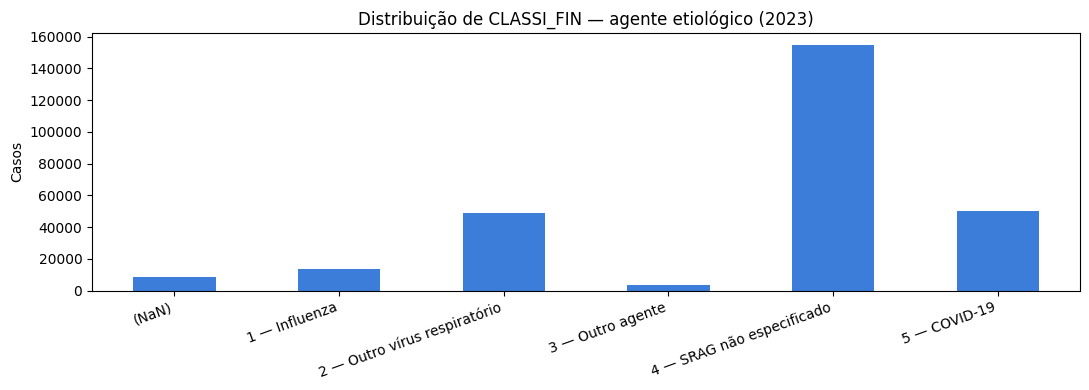

In [13]:
"""Distribuição de CLASSI_FIN."""
classi = df["CLASSI_FIN"].astype("string").fillna("(NaN)")
counts = classi.value_counts(dropna=False).sort_index()

labels = {
    "1": "1 — Influenza",
    "2": "2 — Outro vírus respiratório",
    "3": "3 — Outro agente",
    "4": "4 — SRAG não especificado",
    "5": "5 — COVID-19",
    "(NaN)": "(NaN)",
}
labeled = counts.rename(index=labels)

print("Contagem absoluta:")
print(labeled.to_string())
print()
print("% sobre o total:")
print((labeled / labeled.sum() * 100).round(2).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
labeled.plot(kind="bar", ax=ax, color="#3b7dd8")
ax.set_title("Distribuição de CLASSI_FIN — agente etiológico (2023)")
ax.set_ylabel("Casos")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig_path = FIG_DIR / "04_classi_fin.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()

## Conclusões da Fase 1 — checklist para a Fase 2 (tratamento)

### Achados estruturais

As colunas extras em relação ao dicionário oficial não correspondem a ruído de parsing. Todas têm nomes legítimos do dicionário SIVEP-Gripe. O `config.py` simplesmente não enumera todas: 97 colunas estão fora das listas hardcoded, mas correspondem a códigos IBGE auxiliares (`CO_MUN_NOT`, `CO_REGIONA`), descrições livres (`OUTRO_SIN`, `MORB_DESC`), campos adicionais de antígeno e PCR e campos de vigilância genômica para COVID-19. Nenhum drop estrutural é necessário, e a hipótese de separadores trailing fica descartada.

Em relação aos dtypes do Parquet, 150 colunas vêm como `StringDtype`, 23 como `datetime64[ns]` (parseadas automaticamente pelo pyarrow durante o write) e 21 como `object` (provavelmente `Decimal` em campos numéricos). É o resultado esperado da decisão da Fase 0 de manter strings e adiar o casting.

### Achados de qualidade — drops imediatos para a Fase 2

- **7 colunas 100% missing:** `TABAG`, `DT_RT_VGM`, `PAIS_VGM`, `LO_PS_VGM`, `VG_REINF`, `DT_VGM` e `CO_PS_VGM`, todas vazias na base 2023.
- **21 colunas constantes (um único valor):** `HISTO_VGM` (=0), `FATOR_RISC` (=1), `REINF` (=2) e blocos PCR e AN específicos (`PCR_PARA1..4`, `PCR_VSR`, `PCR_RINO`, `PCR_METAP`, `PCR_ADENO`, `PCR_BOCA`, `PCR_OUTRO`, `PCR_SARS2`, `AN_VSR`, `AN_OUTRO`, `AN_PARA1..3`, `AN_ADENO` e `AN_SARS2`). Vale notar que `FATOR_RISC=1` para todos os registros não significa "todos têm fator de risco"; significa que o campo agregador foi marcado em todo registro válido. Os fatores individuais (`CARDIOPATI`, `DIABETES`, etc.) é que carregam a informação útil.
- **5 colunas quase-constantes (mais de 99% em um valor):** `ID_PAIS=BRASIL`, `CO_PAIS=1`, `POV_CT=2`, `ESTRANG=2` e `FAB_RE_BI` (Pfizer em 99% entre os bivalentes). São dropáveis ou colapsáveis em binárias.

O total de colunas dropáveis sem perda de informação fica em 28 (7 vazias e 21 constantes), com mais 5 quase-constantes a discutir.

### Achados temporais — filtro de período obrigatório

- Range observado: 2023-01-01 a 2025-06-23. A base não está limitada a 2023.
- Distribuição: 276.339 casos em 2023, 3.100 em 2024 e 14 em 2025. Os 3.114 casos (1,1%) fora de 2023 precisam ser filtrados na Fase 2, dado que o escopo do desafio é o ano de 2023.
- Distribuição mensal: pico em maio/2023 (35 mil) e vale em dezembro/2023 (15 mil), em sazonalidade típica de SRAG no inverno (de maio a julho no Brasil).
- Split de 1º contra 2º semestre em 58,2% contra 41,8% é viável e realista. O treino "vê o pico" do inverno e o teste pega outono e início do inverno seguinte. Nesse desenho, o primeiro semestre inclui junho, ou seja, parte do pico, e a sazonalidade vaza parcialmente, o que é aceitável.

### Variável-alvo `EVOLUCAO`

| Código | Rótulo | n | % |
|---|---|---:|---:|
| 1 | Cura | 226.151 | 80,9% |
| 2 | Óbito SRAG | 24.944 | 8,9% |
| 3 | Óbito outras causas | 8.301 | 3,0% |
| 9 | Ignorado | 6.077 | 2,2% |
| (NaN) | | 13.980 | 5,0% |

- Casos modeláveis (códigos 1 e 2): 251.095, ou 89,9% do total.
- Taxa-base de óbito por SRAG: 9,9% entre os modeláveis. Desbalanceamento moderado, o que confirma AUC-PR como métrica primária.

### Variável `CLASSI_FIN` (agente etiológico)

| Código | Rótulo | % |
|---|---|---:|
| 4 | SRAG não especificado | 55,4% |
| 5 | COVID-19 | 18,0% |
| 2 | Outro vírus respiratório | 17,6% |
| 1 | Influenza | 4,8% |
| 3 | Outro agente | 1,3% |
| (NaN) | | 3,0% |

Mais da metade dos casos não tem agente identificado. Isso limita análises por agente etiológico na Fase 3 e exige cautela na Fase 4: `CLASSI_FIN=4` deve ser mantido como categoria válida e não filtrado como missing. A informação "SRAG sem agente identificado" é, em si, um sinal clínico e operacional (laboratório não realizou exame ou resultado inconclusivo). COVID-19 (18%) e VSR-likely (17,6%) já têm peso comparável em 2023, o que reforça que o cenário não é mais COVID-only.

### Checklist para a Fase 2

- Drop de 28 colunas (7 vazias e 21 constantes). Avaliar drop adicional das 5 quase-constantes.
- Filtro temporal mantendo apenas `DT_NOTIFIC.year == 2023`, com descarte de 3.114 casos (1,1%).
- Filtro do target para modelagem: `EVOLUCAO ∈ {1, 2}` (descarta 3, 9 e NaN, com perda de 10,1% das linhas).
- Casting: os 21 dtypes `object` provavelmente contêm `Decimal`; conversão para numérico onde apropriado.
- Idade: unificar `NU_IDADE_N` e `TP_IDADE` (1=dia, 2=mês, 3=ano) em `IDADE_ANOS` (mediana esperada em torno de 60 anos para SRAG hospitalizada).
- Binárias `{1,2,9}` para `{1,0,NaN}`, revisando a lista `BINARY_FIELDS` em `config.py` (alguns campos, como `SUPORT_VEN`, têm 3 valores válidos e não seguem o padrão).
- Datas: parsear todas as colunas em `DATE_COLUMNS` (a maioria já veio como `datetime64`, mas `DT_NOTIFIC` ainda está como string — conferir).
- Missing strategy: decidir caso a caso para as 117 colunas com mais de 50% de missing. Para campos clínicos (sintomas e comorbidades), um indicador binário de "preenchido contra não preenchido" pode preservar o sinal de qualidade do registro.
- Manter `CLASSI_FIN=4` como categoria válida, não como missing, ao longo da Fase 3 e da Fase 4.
- Output da Fase 2: `data/interim/srag_2023_clean.parquet`, com tipos corretos e cerca de 248 mil linhas (após filtros).